# Image Scraping, Augmentation, and Dataset Preparation

**Objective**: Scrape product images from Google Images, augment to reach target count, and prepare CNN training splits.

**Key Steps**:
1. Load stock codes for CNN training
2. Scrape 150 images per product from Google Images
3. Validate downloaded images
4. Augment images to reach 150 per product
5. Split into train/validation/test (70/15/15)
6. Create class mapping for CNN

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shutil
from sklearn.model_selection import train_test_split
import json
from services.scraper_service import ScraperService
from services.augmentation_service import AugmentationService
from PIL import Image
import time

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Stock Codes for CNN Training

In [2]:
# Load stock codes
stock_codes_df = pd.read_csv('../data/CNN_Model_Train_Data_cleaned.csv')
stock_codes = stock_codes_df['StockCode'].tolist()

# Load product descriptions
products_df = pd.read_csv('../data/dataset_cleaned.csv')

# Create mapping
product_mapping = {}
for stock_code in stock_codes:
    product_row = products_df[products_df['StockCode'] == stock_code].iloc[0]
    description = product_row['Description']
    product_mapping[stock_code] = description

print(f"Found {len(product_mapping)} products to scrape:")
for stock_code, description in product_mapping.items():
    print(f"  {stock_code}: {description}")

Found 10 products to scrape:
  22112: CHOCOLATE HOT WATER BOTTLE
  20726: LUNCH BAG WOODLAND
  23298: SPOTTY BUNTING
  22727: ALARM CLOCK BAKELIKE RED
  22077: 6 RIBBONS RUSTIC CHARM
  21931: JUMBO STORAGE BAG SUKI
  22139: RETROSPOT TEA SET CERAMIC 11 PC
  21034: REX CASH+CARRY JUMBO SHOPPER
  22384: LUNCH BAG PINK POLKADOT
  22423: REGENCY CAKESTAND 3 TIER


## 2. Scrape Product Images from Google

In [3]:
# Initialize scraper
scraper = ScraperService(base_dir="../data/product_images", headless=True)
print("✓ Scraper initialized")

✓ Scraper initialized


In [4]:
# Scrape images for each product
results = {}

for stock_code, description in product_mapping.items():
    print(f"\n{'='*70}")
    print(f"Processing: {description} (Stock: {stock_code})")
    print(f"{'='*70}")
    
    try:
        # Scrape images
        image_paths = scraper.scrape_google_images(description, max_images=150)
        
        # Validate images
        product_dir = scraper.base_dir / scraper._sanitize_filename(description)
        valid_count, invalid_files = scraper.validate_images(product_dir)
        
        results[stock_code] = {
            'description': description,
            'downloaded': len(image_paths),
            'valid': valid_count,
            'invalid': len(invalid_files)
        }
        
        print(f"  Downloaded: {len(image_paths)} | Valid: {valid_count} | Invalid: {len(invalid_files)}")
        
        time.sleep(3)
        
    except Exception as e:
        print(f"  Error: {e}")
        results[stock_code] = {
            'description': description,
            'downloaded': 0,
            'valid': 0,
            'invalid': 0
        }

# Close browser
scraper.close()
print("\n✓ Scraping complete")


Processing: CHOCOLATE HOT WATER BOTTLE (Stock: 22112)

Scraping Google Images for: CHOCOLATE HOT WATER BOTTLE
Target: 150 images
  Found 20 valid image elements
  Downloaded: 10/150
  Downloaded: 20/150
  Total downloaded: 20 images
  Downloaded: 20 | Valid: 20 | Invalid: 0

Processing: LUNCH BAG WOODLAND (Stock: 20726)

Scraping Google Images for: LUNCH BAG WOODLAND
Target: 150 images
  Found 20 valid image elements
  Downloaded: 10/150
  Total downloaded: 19 images
  Downloaded: 19 | Valid: 19 | Invalid: 0

Processing: SPOTTY BUNTING (Stock: 23298)

Scraping Google Images for: SPOTTY BUNTING
Target: 150 images
  Found 20 valid image elements
  Downloaded: 10/150
  Total downloaded: 17 images
  Downloaded: 17 | Valid: 17 | Invalid: 0

Processing: ALARM CLOCK BAKELIKE RED (Stock: 22727)

Scraping Google Images for: ALARM CLOCK BAKELIKE RED
Target: 150 images
  Found 20 valid image elements
  Downloaded: 10/150
  Total downloaded: 18 images
  Downloaded: 18 | Valid: 18 | Invalid: 0

Pr

## 3. Scraping Summary

In [5]:
# Create summary DataFrame
summary_df = pd.DataFrame([
    {
        'StockCode': stock_code,
        'Description': result['description'],
        'Downloaded': result['downloaded'],
        'Valid': result['valid'],
        'Invalid': result['invalid']
    }
    for stock_code, result in results.items()
])

print("Scraping Summary:")
print(summary_df.to_string(index=False))

total_downloaded = summary_df['Downloaded'].sum()
total_valid = summary_df['Valid'].sum()
print(f"\nTotal Downloaded: {total_downloaded}")
print(f"Total Valid: {total_valid}")

Scraping Summary:
 StockCode                     Description  Downloaded  Valid  Invalid
     22112      CHOCOLATE HOT WATER BOTTLE          20     20        0
     20726              LUNCH BAG WOODLAND          19     19        0
     23298                  SPOTTY BUNTING          17     17        0
     22727        ALARM CLOCK BAKELIKE RED          18     18        0
     22077          6 RIBBONS RUSTIC CHARM          18     18        0
     21931          JUMBO STORAGE BAG SUKI          20     20        0
     22139 RETROSPOT TEA SET CERAMIC 11 PC          20     20        0
     21034    REX CASH+CARRY JUMBO SHOPPER          20     20        0
     22384         LUNCH BAG PINK POLKADOT          18     18        0
     22423        REGENCY CAKESTAND 3 TIER          17     17        0

Total Downloaded: 187
Total Valid: 187


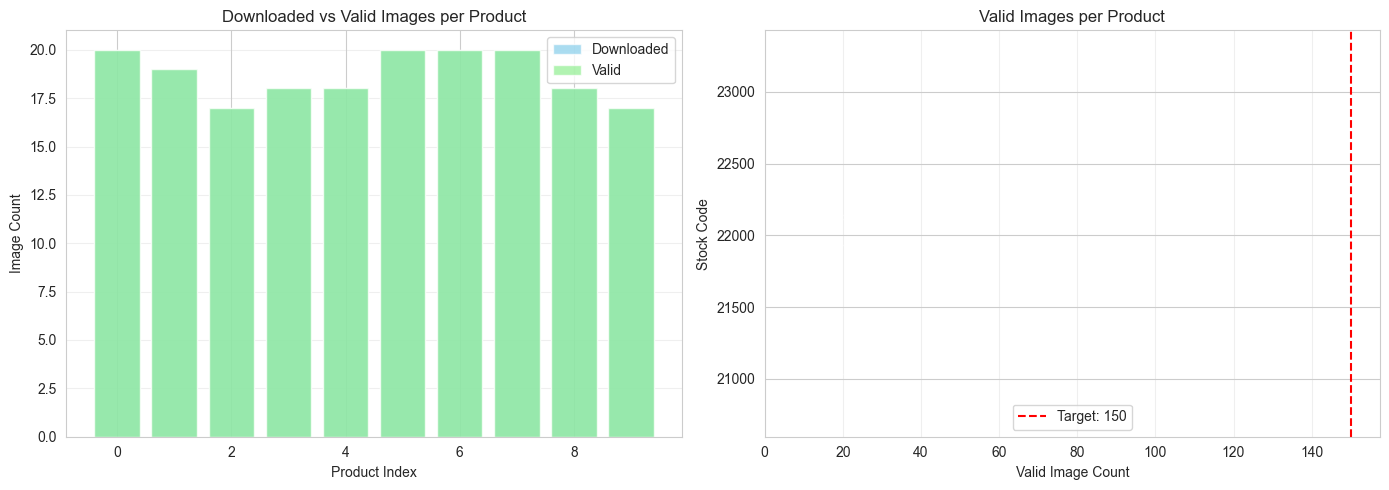

In [6]:
# Visualize scraping results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Downloaded vs Valid
x = range(len(summary_df))
axes[0].bar(x, summary_df['Downloaded'], alpha=0.7, label='Downloaded', color='skyblue')
axes[0].bar(x, summary_df['Valid'], alpha=0.7, label='Valid', color='lightgreen')
axes[0].set_xlabel('Product Index')
axes[0].set_ylabel('Image Count')
axes[0].set_title('Downloaded vs Valid Images per Product')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Per-product breakdown
axes[1].barh(summary_df['StockCode'], summary_df['Valid'], color='green', alpha=0.7)
axes[1].set_xlabel('Valid Image Count')
axes[1].set_ylabel('Stock Code')
axes[1].set_title('Valid Images per Product')
axes[1].axvline(x=150, color='r', linestyle='--', label='Target: 150')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Visualize Sample Images

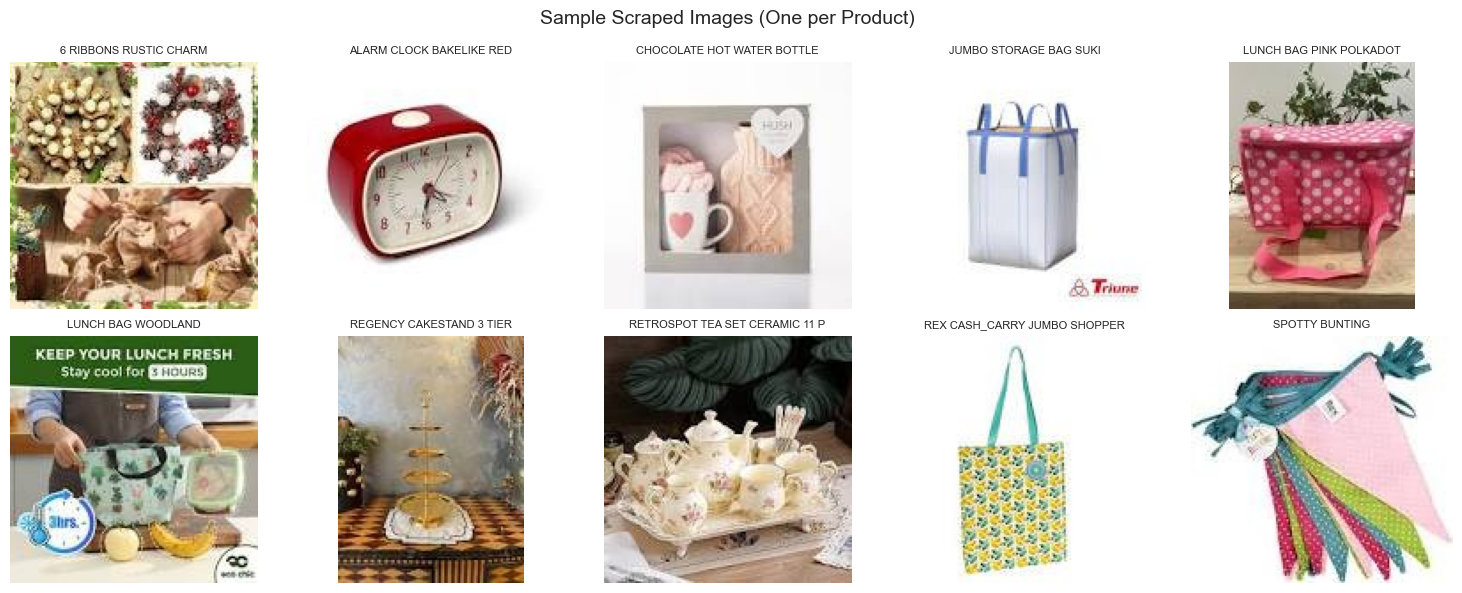

In [7]:
# Display sample images from each product
base_dir = Path('../data/product_images')
product_dirs = [d for d in base_dir.iterdir() if d.is_dir()]

# Show 2 samples per product (2 rows, 5 cols = 10 products)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, product_dir in enumerate(sorted(product_dirs)[:10]):
    image_files = list(product_dir.glob('*.jpg'))[:1]  # First image
    if image_files:
        img = Image.open(image_files[0])
        axes[idx].imshow(img)
        axes[idx].set_title(product_dir.name[:30], fontsize=8)
        axes[idx].axis('off')

plt.suptitle('Sample Scraped Images (One per Product)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Image Augmentation

In [8]:
# Initialize augmentation service
augmenter = AugmentationService()

print(f"Found {len(product_dirs)} product directories")
print(f"Target: 150 images per product\n")

Found 10 product directories
Target: 150 images per product



In [9]:
# Augment each product directory
augmentation_results = {}

for product_dir in sorted(product_dirs):
    product_name = product_dir.name
    print(f"Processing: {product_name}")
    
    final_count = augmenter.augment_product_directory(product_dir, target_per_product=150)
    augmentation_results[product_name] = final_count
    print()

print("✓ Augmentation complete")

Processing: 6 RIBBONS RUSTIC CHARM
    Original images: 18
    Need 132 more images
    Creating 7 augmentations per original image
    Final count: 144 images (126 augmented)

Processing: ALARM CLOCK BAKELIKE RED
    Original images: 18
    Need 132 more images
    Creating 7 augmentations per original image
    Final count: 144 images (126 augmented)

Processing: CHOCOLATE HOT WATER BOTTLE
    Original images: 20
    Need 130 more images
    Creating 6 augmentations per original image
    Final count: 140 images (120 augmented)

Processing: JUMBO STORAGE BAG SUKI
    Original images: 20
    Need 130 more images
    Creating 6 augmentations per original image
    Final count: 140 images (120 augmented)

Processing: LUNCH BAG PINK POLKADOT
    Original images: 18
    Need 132 more images
    Creating 7 augmentations per original image
    Final count: 144 images (126 augmented)

Processing: LUNCH BAG WOODLAND
    Original images: 19
    Need 131 more images
    Creating 6 augmentations

In [10]:
# Augmentation summary
print("="*70)
print("AUGMENTATION SUMMARY")
print("="*70)
for product_name, count in sorted(augmentation_results.items()):
    status = "✓" if count >= 140 else "⚠️"
    print(f"{status} {product_name}: {count} images")

total_images = sum(augmentation_results.values())
print(f"\nTotal Images: {total_images}")
print(f"Average per product: {total_images / len(augmentation_results):.1f}")

AUGMENTATION SUMMARY
✓ 6 RIBBONS RUSTIC CHARM: 144 images
✓ ALARM CLOCK BAKELIKE RED: 144 images
✓ CHOCOLATE HOT WATER BOTTLE: 140 images
✓ JUMBO STORAGE BAG SUKI: 140 images
✓ LUNCH BAG PINK POLKADOT: 144 images
⚠️ LUNCH BAG WOODLAND: 133 images
⚠️ REGENCY CAKESTAND 3 TIER: 136 images
✓ RETROSPOT TEA SET CERAMIC 11 PC: 140 images
✓ REX CASH_CARRY JUMBO SHOPPER: 140 images
⚠️ SPOTTY BUNTING: 136 images

Total Images: 1397
Average per product: 139.7


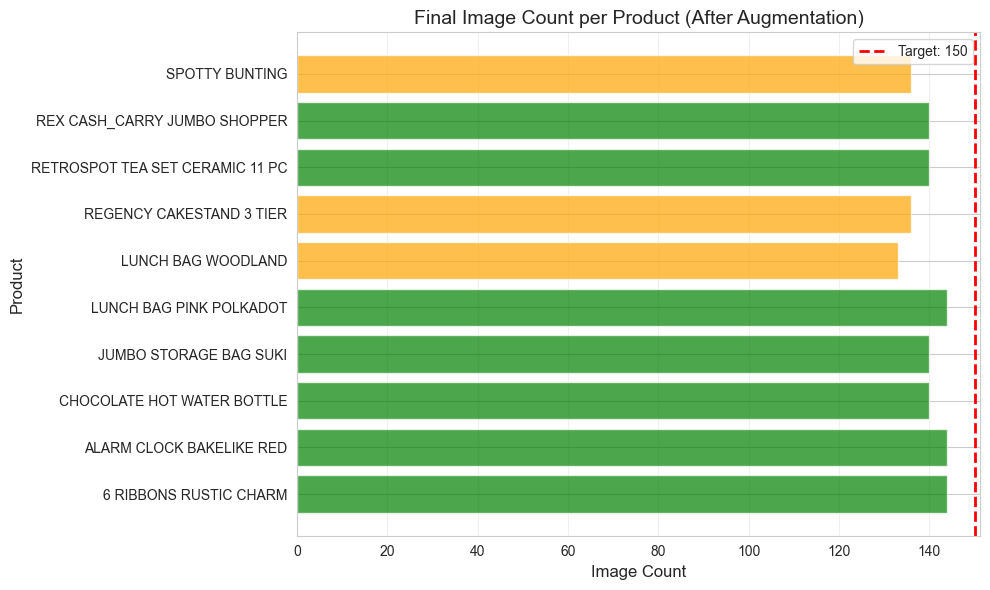

In [11]:
# Visualize final image counts
plt.figure(figsize=(10, 6))
product_names = list(augmentation_results.keys())
counts = list(augmentation_results.values())
colors = ['green' if c >= 140 else 'orange' for c in counts]

plt.barh(product_names, counts, color=colors, alpha=0.7)
plt.xlabel('Image Count', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.title('Final Image Count per Product (After Augmentation)', fontsize=14)
plt.axvline(x=150, color='r', linestyle='--', linewidth=2, label='Target: 150')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Prepare CNN Training Data

In [12]:
# Create mapping CSV
mapping_data = []
for product_dir in product_dirs:
    product_name = product_dir.name
    
    # Find matching stock code
    stock_code = None
    for desc, code in product_mapping.items():
        sanitized_desc = "".join(c if c.isalnum() or c in (' ', '_') else '_' for c in code).strip()
        if sanitized_desc == product_name or code == product_name:
            stock_code = desc
            break
    
    if not stock_code:
        print(f"Warning: Could not find stock code for {product_name}")
        continue
    
    # Add all images
    image_files = list(product_dir.glob('*.jpg'))
    for img_path in image_files:
        mapping_data.append({
            'StockCode': stock_code,
            'Description': product_mapping[stock_code],
            'ImagePath': str(img_path)
        })

mapping_df = pd.DataFrame(mapping_data)
mapping_df.to_csv('../data/CNN_Model_Train_Data.csv', index=False)

print(f"✓ Created CNN_Model_Train_Data.csv with {len(mapping_df)} images")
print(f"\nImages per class:")
print(mapping_df.groupby('StockCode')['ImagePath'].count())

✓ Created CNN_Model_Train_Data.csv with 1397 images

Images per class:
StockCode
20726    133
21034    140
21931    140
22077    144
22112    140
22139    140
22384    144
22423    136
22727    144
23298    136
Name: ImagePath, dtype: int64


## 7. Create Train/Val/Test Splits

In [13]:
# Load CNN training data
df = pd.read_csv('../data/CNN_Model_Train_Data.csv')

print("="*70)
print("CNN DATA PREPARATION")
print("="*70)
print(f"Total images: {len(df)}")
print(f"Total classes: {df['StockCode'].nunique()}")

CNN DATA PREPARATION
Total images: 1397
Total classes: 10


In [14]:
# Create dataset directory structure
dataset_dir = Path('../data/cnn_dataset')
dataset_dir.mkdir(exist_ok=True)

for split in ['train', 'val', 'test']:
    split_dir = dataset_dir / split
    split_dir.mkdir(exist_ok=True)

print("✓ Directory structure created")

✓ Directory structure created


In [15]:
# Split data per class
train_data = []
val_data = []
test_data = []

class_mapping = {}
class_names = {}

split_summary = []

for idx, (stock_code, group) in enumerate(df.groupby('StockCode')):
    class_name = group.iloc[0]['Description']
    class_mapping[stock_code] = idx
    class_names[idx] = class_name
    
    # Create class directories
    for split in ['train', 'val', 'test']:
        class_dir = dataset_dir / split / str(stock_code)
        class_dir.mkdir(exist_ok=True)
    
    # Split: 70% train, 15% val, 15% test
    images = group['ImagePath'].tolist()
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)
    
    split_summary.append({
        'StockCode': stock_code,
        'Class': class_name,
        'Total': len(images),
        'Train': len(train_imgs),
        'Val': len(val_imgs),
        'Test': len(test_imgs)
    })
    
    # Copy images
    for img_path in train_imgs:
        src = Path(img_path)
        dst = dataset_dir / 'train' / str(stock_code) / src.name
        shutil.copy2(src, dst)
        train_data.append({
            'image_path': str(dst),
            'stock_code': stock_code,
            'description': class_name,
            'class_id': idx
        })
    
    for img_path in val_imgs:
        src = Path(img_path)
        dst = dataset_dir / 'val' / str(stock_code) / src.name
        shutil.copy2(src, dst)
        val_data.append({
            'image_path': str(dst),
            'stock_code': stock_code,
            'description': class_name,
            'class_id': idx
        })
    
    for img_path in test_imgs:
        src = Path(img_path)
        dst = dataset_dir / 'test' / str(stock_code) / src.name
        shutil.copy2(src, dst)
        test_data.append({
            'image_path': str(dst),
            'stock_code': stock_code,
            'description': class_name,
            'class_id': idx
        })

print("✓ Images copied to splits")

✓ Images copied to splits


## 8. Split Summary

In [16]:
# Display split summary
split_df = pd.DataFrame(split_summary)
print("\nSplit Summary per Class:")
print(split_df.to_string(index=False))


Split Summary per Class:
 StockCode                           Class  Total  Train  Val  Test
     20726              LUNCH BAG WOODLAND    133     93   20    20
     21034    REX CASH+CARRY JUMBO SHOPPER    140     98   21    21
     21931          JUMBO STORAGE BAG SUKI    140     98   21    21
     22077          6 RIBBONS RUSTIC CHARM    144    100   22    22
     22112      CHOCOLATE HOT WATER BOTTLE    140     98   21    21
     22139 RETROSPOT TEA SET CERAMIC 11 PC    140     98   21    21
     22384         LUNCH BAG PINK POLKADOT    144    100   22    22
     22423        REGENCY CAKESTAND 3 TIER    136     95   20    21
     22727        ALARM CLOCK BAKELIKE RED    144    100   22    22
     23298                  SPOTTY BUNTING    136     95   20    21


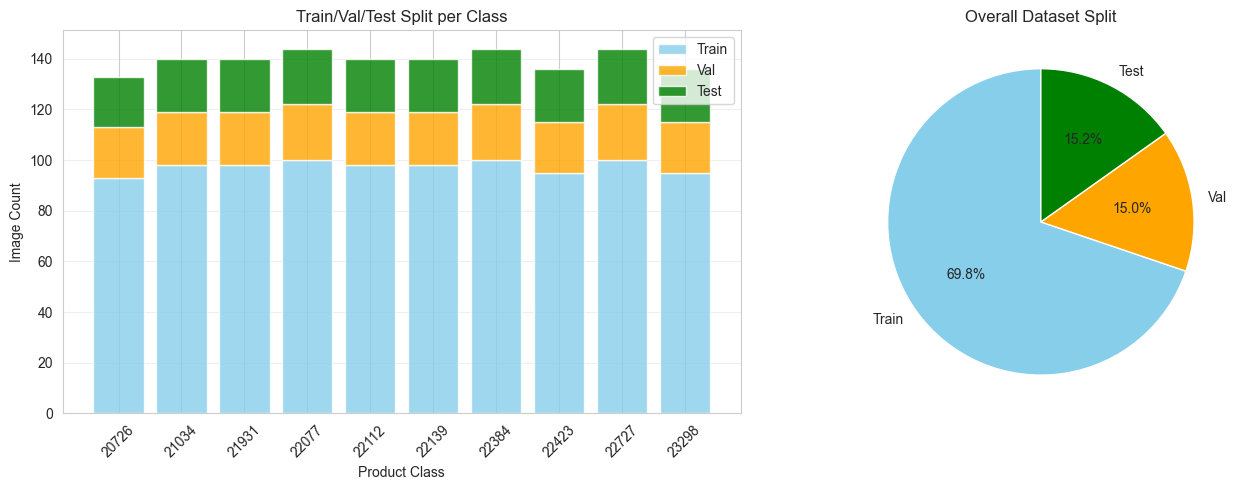


Total Train: 975 (69.8%)
Total Val: 210 (15.0%)
Total Test: 212 (15.2%)


In [17]:
# Visualize splits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
x = range(len(split_df))
axes[0].bar(x, split_df['Train'], label='Train', color='skyblue', alpha=0.8)
axes[0].bar(x, split_df['Val'], bottom=split_df['Train'], label='Val', color='orange', alpha=0.8)
axes[0].bar(x, split_df['Test'], bottom=split_df['Train']+split_df['Val'], label='Test', color='green', alpha=0.8)
axes[0].set_xlabel('Product Class')
axes[0].set_ylabel('Image Count')
axes[0].set_title('Train/Val/Test Split per Class')
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_df['StockCode'], rotation=45)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
total_train = split_df['Train'].sum()
total_val = split_df['Val'].sum()
total_test = split_df['Test'].sum()
axes[1].pie(
    [total_train, total_val, total_test],
    labels=['Train', 'Val', 'Test'],
    autopct='%1.1f%%',
    colors=['skyblue', 'orange', 'green'],
    startangle=90
)
axes[1].set_title('Overall Dataset Split')

plt.tight_layout()
plt.show()

print(f"\nTotal Train: {total_train} ({total_train/len(df)*100:.1f}%)")
print(f"Total Val: {total_val} ({total_val/len(df)*100:.1f}%)")
print(f"Total Test: {total_test} ({total_test/len(df)*100:.1f}%)")

## 9. Save Split Data

In [18]:
# Save split CSVs
train_df = pd.DataFrame(train_data)
val_df = pd.DataFrame(val_data)
test_df = pd.DataFrame(test_data)

train_df.to_csv('../data/cnn_train.csv', index=False)
val_df.to_csv('../data/cnn_val.csv', index=False)
test_df.to_csv('../data/cnn_test.csv', index=False)

print("✓ Saved cnn_train.csv")
print("✓ Saved cnn_val.csv")
print("✓ Saved cnn_test.csv")

✓ Saved cnn_train.csv
✓ Saved cnn_val.csv
✓ Saved cnn_test.csv


In [19]:
# Save class mapping
mapping_info = {
    'class_mapping': class_mapping,
    'class_names': class_names,
    'num_classes': len(class_mapping)
}

with open('../data/class_mapping.json', 'w') as f:
    json.dump(mapping_info, f, indent=2)

print("✓ Saved class_mapping.json")
print(f"\nClass Mapping:")
for class_id, name in sorted(class_names.items()):
    stock_code = list(class_mapping.keys())[list(class_mapping.values()).index(class_id)]
    print(f"  Class {class_id}: {stock_code} - {name}")

✓ Saved class_mapping.json

Class Mapping:
  Class 0: 20726 - LUNCH BAG WOODLAND
  Class 1: 21034 - REX CASH+CARRY JUMBO SHOPPER
  Class 2: 21931 - JUMBO STORAGE BAG SUKI
  Class 3: 22077 - 6 RIBBONS RUSTIC CHARM
  Class 4: 22112 - CHOCOLATE HOT WATER BOTTLE
  Class 5: 22139 - RETROSPOT TEA SET CERAMIC 11 PC
  Class 6: 22384 - LUNCH BAG PINK POLKADOT
  Class 7: 22423 - REGENCY CAKESTAND 3 TIER
  Class 8: 22727 - ALARM CLOCK BAKELIKE RED
  Class 9: 23298 - SPOTTY BUNTING


## Summary

### Scraping Results:
- Scraped images from Google Images for {len(product_mapping)} products
- Total images downloaded: {total_downloaded}
- Total valid images: {total_valid}

### Augmentation:
- Augmented images to reach ~150 per product
- Total images after augmentation: {total_images}
- Augmentation techniques: rotation, flip, brightness, contrast

### Dataset Split:
- Train: {total_train} images (70%)
- Validation: {total_val} images (15%)
- Test: {total_test} images (15%)
- Total: {total_train + total_val + total_test} images
- Classes: {len(class_mapping)}

### Next Steps:
Proceed to CNN model training with the prepared dataset.